In [61]:
import os
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

In [62]:
load_dotenv(".env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_SECRET_KEY")
embeddings = HuggingFaceEmbeddings()

In [63]:
files = [
    ("ciso", "../data/corpus_ciso_threat_intel.txt"),
    ("fintech", "../data/corpus_fintech_entity_generation.txt"),
    ("hacker", "../data/corpus_hacker_attacks.txt"),
    ("sre", "../data/corpus_sre_optimizations.txt")
]

headers_to_split_on = [ ("####", "section_title") ]
splitter = MarkdownHeaderTextSplitter(headers_to_split_on = headers_to_split_on)
all_docs = []

for agent_name, file_path in files:
    with open(file_path, 'r') as f:
        content = f.read()
        
    chunks = splitter.split_text(content)
    
    for doc in chunks:
        doc.metadata["agent"] = agent_name
        
    all_docs.extend(chunks)

In [64]:
vectorstore = FAISS.from_documents(all_docs, embeddings)

In [65]:
vectorstore.save_local("../data/vector_db/unified_kb")

In [66]:
db = FAISS.load_local("../data/vector_db/unified_kb/", embeddings, allow_dangerous_deserialization=True)

@tool
def similarity_search(query, agent_name, k=2) -> list:
    """
    Recherche dans la base de connaissances (Knowledge Base) pour obtenir des détails 
    techniques, des tactiques MITRE ATT&CK ou des patterns SRE/Fintech.
    Paramètres:
    - query: La chaîne de recherche sémantique.
    - agent_name: Le filtre obligatoire ('ciso', 'sre', 'hacker' ou 'fintech').
    """
    return  db.similarity_search(query, k=k, filter = {"agent": agent_name})
    

In [67]:
test_scenarios = {
    "ciso": [
        "stratégies de défense contre le ransomware",
        "implémentation du zero-trust"
    ],
    "sre": [
        "optimisation de la latence de base de données",
        "plan de reprise d'activité (DRP) cloud"
    ],
    "hacker": [
        "techniques d'escalade de privilèges",
        "exploitation de vulnérabilités API"
    ],
    "fintech": [
        "détection de schémas de blanchiment",
        "règles de conformité KYC automatisées"
    ]
}

for agent, queries in test_scenarios.items():
    print(f"\n=== TESTS POUR L'AGENT : {agent.upper()} ===")
    for q in queries[:1]:
        print(f"\n🔍 Query: {q}")
        docs = similarity_search.invoke({"query": q, "agent_name": agent, "k": 2})
        
        for i, doc in enumerate(docs[:1]):
            title = doc.metadata.get('section_title', 'Sans titre')
            print(f"  Result {i+1} [{title}]: {doc.page_content[:150]}...")


=== TESTS POUR L'AGENT : CISO ===

🔍 Query: stratégies de défense contre le ransomware
  Result 1 [Incident Response Playbooks (IR Procedures)]: - **Category**: detection (prep/response)
- **What it defends against**: All listed, as it enables recovery; specifically ransomware (T1486), DDoS (T1...

=== TESTS POUR L'AGENT : SRE ===

🔍 Query: optimisation de la latence de base de données
  Result 1 [Comparative Analysis of Patterns]: The following tables provide overviews for quick reference.  
**Table 1: Pattern Impacts on Key Metrics**  
| Pattern                  | Throughput Sc...

=== TESTS POUR L'AGENT : HACKER ===

🔍 Query: techniques d'escalade de privilèges
  Result 1 [Technique: Insider Threats from Compromised Employee Accounts]: - **Category**: compromise
- **Prerequisites**: Compromised credentials (e.g., via phishing); insider access privileges; poor monitoring of internal a...

=== TESTS POUR L'AGENT : FINTECH ===

🔍 Query: détection de schémas de blanchiment
  Result 1 [

In [68]:
from typing import Optional, List
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict, Optional, List
from langgraph.graph.message import add_messages
from langchain_core.tools.retriever import create_retriever_tool

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    game_state: dict

class AgentRecommendation(BaseModel):
    action_id: str = Field(description="L'identifiant technique de l'action")
    target: Optional[str] = Field(description = "L'ID du node visé, ou None si action globale", default=None)
    cost: int = Field(description="le cout de l'action (en €K pour CISO/SRE, en ActionPoints pour Byte)")
    reasoning: str = Field(description="Justification strategique narrative de l'action")
    
ciso_retriever = db.as_retriever(
    search_kwargs = {'filter': {'agent': 'ciso'}, 'k': 3}
)

ciso_tool = create_retriever_tool(
    ciso_retriever,
    "ciso_kb",
    "Use this to search for cybersecurity defense patterns, playbooks, and MITRE tactics."
)
    

In [69]:
# Ancienne syntaxe
#
# class BaseAgent:
#     def __init__(self, role: str, bias: str, kb_name: str, actions: List[dict]):
#         self.role = role
#         self.bias = bias
#         self.kb_name = kb_name
#         self.actions = actions
        
#         self.parser = PydanticOutputParser(pydantic_object=AgentRecommendation)
        
#         self.llm = ChatOpenAI(
#             model = "gpt-5-nano",
#             temperature = 0
#         ).bind_tools([similarity_search])
        
        
#     def _get_system_prompt(self) -> str:
#         return f""" 
#     Tu es un expert agissant en tant que {self.role}.
#     Ton biais strategique est : {self.bias}.
    
#     Actions possibles (ID, Nom, Cout) : {self.actions}.
    
#     {self.parser.get_format_instructions()}
#     """
    
    
#     def recommend(self, state: dict):
#         messages = [
#             SystemMessage(content = self._get_system_prompt()),
#             HumanMessage(content = f"GAME STATE: {state}")
#         ]
        
#         res = self.llm.invoke(messages)
        
#         if res.tool_calls:
#             messages.append(res)
            
#             for tool_call in res.tool_calls:
                
#                 observation = similarity_search.invoke(tool_call["args"])
                
                

In [ ]:
llm = ChatOpenAI(
    model = "gpt-5-nano",
    temperature = 0,
    max_completion_tokens = 2000,
    model_kwargs = {"reasoning": {"effort": "low"}},  # réduit le thinking interne
)

# 2. Nœud 'agent' : Décide s'il doit utiliser la KB
def call_agent(state: AgentState):
    # Injecte le game_state dans le system prompt pour que le LLM le voie
    game_ctx = str(state.get("game_state", {}))
    messages = [
        {"role": "system", "content": f"Tu es le CISO. Analyse le Game State et utilise la ciso_kb si besoin.\n\nGAME STATE:\n{game_ctx}"},
    ] + state["messages"]
    
    response = llm.bind_tools([ciso_tool]).invoke(messages)
    return {"messages": [response]}


# 3. Nœud 'generate' : Produit la recommandation finale structurée
def generate_recommendation(state: AgentState):
    structured_llm = llm.with_structured_output(AgentRecommendation)
    recommendation = structured_llm.invoke(state["messages"])
    
    # Convertir en message pour que LangGraph accepte le résultat
    from langchain_core.messages import AIMessage
    response = AIMessage(content=recommendation.model_dump_json())
    
    return {"messages": [response]}

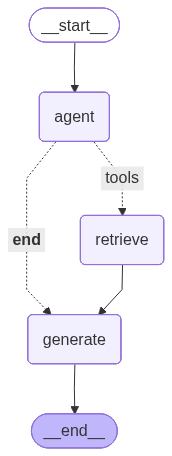

In [77]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

workflow = StateGraph(AgentState)
workflow.add_node("agent", call_agent)
workflow.add_node("retrieve", ToolNode([ciso_tool]))
workflow.add_node("generate", generate_recommendation)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: "generate"})
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

ciso_agent = workflow.compile()

display(Image(ciso_agent.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

# 1. Préparation du Fake Game State (Ticket AGT-1)
fake_state = {
    "company": {
        "cash": 1000, 
        "compliance": 0.7, 
        "reputation": 0.9, 
        "turn": 1, 
        "sector": "Fintech"
    },
    "nodes": [
        {"id": "node_1", "name": "Gateway", "type": "api", "defense": 3, "visibility": 8, "compromised": False},
        {"id": "node_2", "name": "Vault", "type": "db", "defense": 9, "visibility": 2, "compromised": False}
    ],
    "flows": [
        {"name": "Checkout", "node_path": ["node_1", "node_2"], "base_revenue": 50, "is_active": True}
    ]
}

# 2. Lancement du test
print("🚀 Lancement du CISO Agent Graph...")
inputs = {
    "messages": [HumanMessage(content="Analyse la situation et recommande une action de défense.")],
    "game_state": fake_state
}

# On utilise stream pour voir les étapes (agent -> retrieve -> generate)
for output in ciso_agent.stream(inputs, config={"configurable": {"thread_id": "test_v4"}}):
    for key, value in output.items():
        print(f"\n--- Nœud exécuté : {key} ---")
        if value and "messages" in value:
            last_msg = value["messages"][-1]
            # Si c'est un appel d'outil, on affiche les arguments
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"🛠️ Appel d'outil : {last_msg.tool_calls[0]['name']}")
                print(f"📝 Query : {last_msg.tool_calls[0]['args']}")  
            else:
                print(f"💬 Réponse : {last_msg.content[:200]}...")

🚀 Lancement du CISO Agent Graph...

--- Nœud exécuté : agent ---
🛠️ Appel d'outil : ciso_kb

--- Nœud exécuté : retrieve ---
💬 Réponse : ### Key Points
- **Research suggests** that network segmentation, zero-trust architecture, and vulnerability scanning are among the most effective defenses for small fintech infrastructures, potential...

--- Nœud exécuté : generate ---
💬 Réponse : {"action_id":"defense_zero_trust_implementation","target":"ZeroTrust-Deployment","cost":120,"reasoning":"Priorité élevée: le système Vault/DB est à faible visibilité et sensible aux mouvements latérau...


/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(PydanticSerializationUnexpectedValue: Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=AgentRecommendation(actio...nse 9, visibilidad 7).'), input_type=AgentRecommendation]
PydanticSerializationUnexpectedValue: Expected `ResponseOutputRefusal` - serialized value may not be as expected [field_name='content', input_value=ParsedResponseOutputText[...se 9, visibilidad 7).')), input_type=ParsedResponseOutputText[~TextFormatT]])
  PydanticSerializationUnexpectedValue(Expected `ParsedResponseFunctionToolCall` - serialized value may not be as expected [field_name='output', input_value=ParsedResponseOutputMessa...e='message', phase=None), input_type=ParsedResponseOutputMessage[~TextFormatT]])
  PydanticSerializationUnexpectedValue(Expected `ResponseFileSearchToolCall` - serialized value may n